In [174]:
from utils import * 
import json 
from Bio.Align import PairwiseAligner
from fasta import FASTAFile
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
import scipy.cluster.hierarchy
import networkx as nx
 
bz_0_host_genome_id = 'SR-VP_Bioreactor_ck_bot_05_17_2025_Black_host_Methanoperedens_44_40'
bz_0_host_rps3_gene_id = 'SR-VP_Bioreactor_ck_bot_05_17_2025_scaffold_5610_11'
bz_0_host_rps3_seq = re.sub(r'\s', '', '''
ATGGGAGTAGAAAGAAAATTCGTTAAGAACGGTCTTGATAAGGCTCAGATGGAGGAATAC
TTTTCCAAACAACTGGAAAGGGCTGGTTACGGTGGCATGAACATCAATAGAACCCCCATG
GGCACCCAGGTCACTATAGTCGCCGAAAAACCGGGCATGATAATCGGAAAAGGCGGCAAG
ACCATACACAAGCTTACCCATGACCTTGAAACCATCTTCCGCGTGGACAATCCCCAGATA
GATGTTCAGGAAGAAAAAGTTCCTGAACTGAATGCGCAGATGATGGCGTCCCGCCTTGCA
GGAGCCATAGAACGAGGGCTATACTTCCGCAAAGCCGGTCATAACATGCTTCGAAGGATA
CTGGAATCCGGGGCACTTGGATGCGAGATTGATATCGCAGGCAAGCTCACGGGTCCCAGA
AAAAAGACCGAGAAGTTCGTGGGAGGTAATATGCTCCATGCCGGCAACCCTGCCATGGAA
CTGGTAGATAACGGATTTGCCATCGCGATTAAAAAACTGGGAGTTATCGGTTGCCGTGTG
CGGCTGATCAGACCCACTGTTAAACTTCCGGGAAGATTCAAAACCATCCAGATAGCAGCT
GCGCAGGTTCCGCAGGGCGCTGCAGAAAAGAAACCAGCCGGCATTCCCGAAATTGTGAAG
GCTGCTCCAGCTCCAAAAGAAGTAAAACCAGAAGCTATACCTGTGCCTGAGGCTCCGAAA
GAAACTTTACCAGAGGAAACTCGTGCTGCCAACGTCGAAGAGCGGATGCACGGCGATGTC
ATGGAACACAAGCATCCGGAATACGATTACTGGCATCCTGCTTCACGCCTTCATAAAAAG
GAGGAGAAGTAA''')

%load_ext autoreload 
%autoreload 2

plt.rcParams['axes.prop_cycle'] = cycler(color=["#202020","#606060","#808080","#A0A0A0","#BFBFBF","#D9D9D9"])

DATA_DIR = '../data/sr-vp'

# Note that when making the lists, matching annotations which contain only "rps3" results in false positives, as some proteins have descriptions which describe rps3-based 
# taxonomy are also flagged, e.g. "...organism_desc=Sibling to OP3 based on rpS3."

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [175]:
len(bz_0_host_rps3_seq)

852

In [176]:
def load_coverm(path:str):
    '''coverm data has a column per sample and per metric. Columns are of the form {reads_path} {metric}.'''
    metrics = ['Trimmed Mean', 'Mean',  'Covered Bases', 'Covered Fraction', 'Variance', 'Read Count', 'RPKM', 'TPM', 'Length']
    column_pattern = r'(?P<sample_id>[A-Za-z0-9_]+) (?P<metric>.+)$'
    
    df = pd.read_csv(path, sep='\t')
    df = df.rename(columns={'Contig':'contig_id'})
    df = df.melt(id_vars='contig_id', var_name='column', value_name='value').reset_index()
    df = pd.concat([df.drop(columns=['column']).copy(), df['column'].str.extract(column_pattern)], axis=1)
    df = df[df.metric.isin(metrics)].copy() # Some weirdness with duplicate columns (e.g. Mean.1) being created, not sure why. 
    df['metric'] = df['metric'].apply(lambda metric : metric.replace(' ', '_').lower())
    df = df.pivot(values='value', columns='metric', index=['contig_id', 'sample_id']).reset_index()
    df.columns.name = ''
    return df

In [177]:
# Want to look at co-occurrence patterns of the two Betazoids we have in the SR-VP samples. 

# First need to look at what Methanoperedens are present. We have 77 complete and partial genomes https://ggkbase.berkeley.edu/MpSRVP/organisms
SRVP_SAMPLE_METADATA_DF = pd.read_csv('../data/sr-vp/sample_metadata.csv')
SRVP_SAMPLE_METADATA_DF = SRVP_SAMPLE_METADATA_DF[SRVP_SAMPLE_METADATA_DF.regime == 'Illumina'].copy()


In [178]:
def load_ggkbase_fasta(path:str):
    df = FASTAFile.from_file(path).to_df()
    df['project_id'] = [id_.split('|')[2] for id_ in df.index]
    df['gene_id'] = [id_.split('|')[0] for id_ in df.index]
    df['bin_id'] = [id_.split('|')[1] for id_ in df.index]
    df = df.set_index('gene_id')
    return df

In [179]:
# I don't necessarily trust the taxonomy assignments on ggKbase, particularly because they are not particulary detailed or standardized. 
# Instead, I did the following:
#   (1) Obtained all SR-VP rps3 nucleotide sequences assigned as archaeal, unkown, or eukaryotic using ggKbase lists (./data/archaea_rps3.fna). 
#   (2) Obtained all archaeal marker genes in the TIGR01008.fna file from the latest GTDB release (under genomic_files_all/ar53_marker_genes_all.tar.gz). 
#       The ID of each sequence is its corresponding genome. 
#   (3) Constructed a BLAST nucleotide database on biotite using the GTDB genes (n=20119). 
#   (4) Ran BLASTn against the GTDB database on biotite. blastn
#        -db /home/philippar/db/gtdb_archaea_rps3 -out archaea_rps3_blast-gtdb_archaea_rps3.tsv -query /home/philippar/betazoid/sr-vp/archaea_rps3.fna -outfmt "6 qseqid sseqid pident length evalue bitscore qstart qend sstart send" -max_hsps 1 -max_target_seqs 50
#   (5) Used the strongest BLASTn hit from GTDB to assign taxonomy to each rps3 sequence.  


In [180]:
archaea_rps3_df = load_ggkbase_fasta('../data/sr-vp/archaea_rps3.fna') # Obtained using the ggKbase lists utility, filtered for Archaeal and unknown taxonomy.
mp_srvp_rps3_df = load_ggkbase_fasta('../data/sr-vp/MpSRVP_rps3.faa')

print('Number of rps3 sequences assigned Archaeal or unknown taxonomy in SR-VP samples:', archaea_rps3_df.index.nunique())
print('Number of rps3 sequences identified in the MpSRVP project:', mp_srvp_rps3_df.index.nunique())
print('Number of rps3 sequences in the MpSRVP project assigned archaeal, unknown, or eukaryotic taxonomy:', mp_srvp_rps3_df.index.isin(archaea_rps3_df.index.values).sum())


Number of rps3 sequences assigned Archaeal or unknown taxonomy in SR-VP samples: 6793
Number of rps3 sequences identified in the MpSRVP project: 62
Number of rps3 sequences in the MpSRVP project assigned archaeal, unknown, or eukaryotic taxonomy: 62


In [181]:
mp_rps3_contigs_df.description.str.contains('Black').sum()
# mp_rps3_contigs_df.columns
mp_rps3_contigs_df[mp_rps3_contigs_df.description.str.contains('Black')].taxonomy.tolist()
bz_0_host_rps3_gene_id in mp_rps3_contigs_df.index.values

().sum()

AttributeError: 'tuple' object has no attribute 'sum'

In [ ]:
BLAST_FIELDS = ['gene_id', 'subject_gene_id', 'percent_identity', 'alignment_length', 'e_value', 'bit_score', 'query_start', 'query_end', 'subject_start', 'subject_end']
GTDB_TAXONOMY_PATTERN = r'd__(?P<domain>[^;]+);p__(?P<phylum>[^;]+);c__(?P<class>[^;]+);o__(?P<order>[^;]+);f__(?P<family>[^;]+);g__(?P<genus>[^;]+);s__(?P<species>[^$]+)'

archaea_rps3_blast_df = pd.read_csv('../data/sr-vp/archaea_rps3_blast-gtdb_archaea_rps3.tsv', sep='\t', names=BLAST_FIELDS)
archaea_rps3_blast_df['gene_id'] = [gene_id.split('|')[0] for gene_id in archaea_rps3_blast_df.gene_id]
archaea_rps3_blast_df['subject_genome_id'] = archaea_rps3_blast_df.subject_gene_id
archaea_rps3_blast_df['subject_taxonomy'] = archaea_rps3_blast_df.subject_genome_id.map(pd.read_csv('../data/sr-vp/gtdb_archaea_taxonomy.tsv', sep='\t', index_col=0, names=['taxonomy']).taxonomy)
archaea_rps3_blast_df = pd.concat([archaea_rps3_blast_df, archaea_rps3_blast_df.subject_taxonomy.str.extract(GTDB_TAXONOMY_PATTERN)], axis=1)
archaea_rps3_blast_df = archaea_rps3_blast_df.sort_values('bit_score', ascending=False).copy() # So when duplicates are dropped, the strongest hit is retained.

filters = dict()
filters['short_alignment'] = archaea_rps3_blast_df.alignment_length < 100
filters['low_percent_identity'] = archaea_rps3_blast_df.percent_identity < 80 

archaea_rps3_blast_df = apply_filters(filters, archaea_rps3_blast_df)
assert np.all(mp_srvp_rps3_df.index.isin(archaea_rps3_blast_df.gene_id)), 'Methanoperedens from the MpSRVP project are not represented in the filtered BLAST output.'

taxonomy_cols = ['domain', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'percent_identity']
archaea_rps3_df = archaea_rps3_df.drop(columns=taxonomy_cols, errors='ignore')
archaea_rps3_df = archaea_rps3_df.merge(archaea_rps3_blast_df.drop_duplicates('gene_id').set_index('gene_id')[taxonomy_cols], how='left', left_index=True, right_index=True)
archaea_rps3_df['contig_id'] = ['_'.join(id_.split('_')[:-1]) for id_ in archaea_rps3_df.index]
archaea_rps3_df['has_blast_hit'] = archaea_rps3_df.index.isin(archaea_rps3_blast_df.gene_id.unique())
archaea_rps3_df['in_mp_srvp'] = archaea_rps3_df.index.isin(mp_srvp_rps3_df.index.values)
archaea_rps3_df['length'] = archaea_rps3_df.seq.apply(len)
assert np.all(mp_srvp_rps3_df.index.isin(archaea_rps3_blast_df.gene_id)), 'Methanoperedens from the MpSRVP project are not represented in the filtered BLAST output.'

filters = dict()
filters['not_methanoperedens'] = archaea_rps3_df.genus != 'Methanoperedens'
filters['partial_gene'] = archaea_rps3_df.seq.apply(len) < 600

mp_rps3_df = apply_filters(filters, archaea_rps3_df)

print('\nNumber of rps3 with a BLAST hit:', archaea_rps3_blast_df.gene_id.nunique())
print('Number of rps3 with no BLAST hits:', (~archaea_rps3_df.has_blast_hit).sum())
print('Number of Methanoperedens rps3:', len(mp_rps3_df))

assert bz_0_host_rps3_gene_id in mp_rps3_df.index, 'The bz_0 host is missing from the set of Methanoperedens. '


apply_filters: 906 entries removed by short_alignment.
apply_filters: 30140 entries removed by low_percent_identity.
apply_filters: 6389 entries removed by not_methanoperedens.
apply_filters: 1276 entries removed by partial_gene.

Number of rps3 with a BLAST hit: 4041
Number of rps3 with no BLAST hits: 2752
Number of Methanoperedens rps3: 364


In [ ]:
# To achieve slightly more robust taxonomy groups, I decided to extend the detected rps3 genes beyond the ORF boundaries. 
#   (1) Obtained the full contigs from the rps3 in mp_rps3_df from Shufei, along with the coverage and taxonomy (included in FASTA headers).
#   (2) Extended each rps3 gene beyond the ORF by between 100-500 bp, depending on the length of the source contig. 
#   (3) Used MMseqs to align and cluster all rps3 (for greater control over the clustering conditions). 
#   (4) Selected the longest representative sequence from each cluster and used bbmap to map reads, with the --ambiguous all flag. 

def load_mp_rps3_contigs(path:str='../data/sr-vp/mp_rps3_contigs.txt'):
    parse_header = lambda header : dict(zip(['id', 'contig_id', 'coverage', 'taxonomy'], header.split('|')))
    df = FASTAFile.from_file(path).to_df()
    df['description'] = df.index + df.description # The BioPython FASTA parser does not handle the descriptions correctly for this file. 
    df = df.reset_index(drop=True)
    df = pd.concat([df, pd.DataFrame.from_records(df.description.apply(parse_header))], axis=1)
    df['length'] = df.seq.apply(len)
    df = df.drop_duplicates('contig_id').set_index('contig_id')
    return df

mp_rps3_contigs_df = load_mp_rps3_contigs()
print('Minimum contig length:', mp_rps3_contigs_df.seq.apply(len).min())
print('Maximum contig length:', mp_rps3_contigs_df.seq.apply(len).max())

Minimum contig length: 1007
Maximum contig length: 4112728


In [ ]:
delta = 500

assert 'original_length' not in mp_rps3_df.columns, 'rps3 ORFs have already been extended.'

for row in tqdm(mp_rps3_df.itertuples(), desc='Extending sequences beyond rps3 ORF.'):
    contig = mp_rps3_contigs_df.loc[row.contig_id].seq

    match_ = re.search(row.seq, contig)
    if match_ is None:
        contig = reverse_complement(contig)
        match_ = re.search(row.seq, contig)

    start, end = match_.start(), match_.end()
    start = max(start - delta, 0)
    end = min(end + delta, len(contig))

    mp_rps3_df.loc[row.Index, 'original_length'] = len(row.seq)
    mp_rps3_df.loc[row.Index, 'seq'] = contig[start:end]
    mp_rps3_df.loc[row.Index, 'length'] = end - start
    mp_rps3_df.loc[row.Index,'left_extension_length'] = match_.start() - start 
    mp_rps3_df.loc[row.Index,'right_extension_length'] = end - match_.end()

FASTAFile.from_df(mp_rps3_df).write('../data/sr-vp/mp_rps3.fna')
FASTAFile.from_df(mp_rps3_df).write('mp_rps3.fna')

In [ ]:
print('Minimum extended ORF length:', mp_rps3_df.seq.apply(len).min())
print('Maximum extended ORF length:', mp_rps3_df.seq.apply(len).max())

DATA_DIR = '/home/prichter/Documents/banfield/betazoid/data/sr-vp'
MMSEQS_DIR = os.path.join(DATA_DIR, 'mmseqs')

MMSEQS_SEARCH_FIELDS = 'query,target,fident,alnlen,qcov,tcov,qstart,qend,tstart,tend,qlen,tlen'
MMSEQS_DATABASE_NAME = 'mp_rps3'
MMSEQS_DATABASE_PATH = os.path.join(MMSEQS_DIR, 'db', MMSEQS_DATABASE_NAME)
MMSEQS_INPUT_PATH = os.path.join(DATA_DIR, 'mp_rps3.fna')

cmd = f'\nmmseqs createdb  {MMSEQS_INPUT_PATH} {MMSEQS_DATABASE_PATH} --dbtype 2'
cmd += f'\nmmseqs search {MMSEQS_DATABASE_PATH} {MMSEQS_DATABASE_PATH} {MMSEQS_DATABASE_PATH}.out {MMSEQS_DIR}/tmp --search-type 3'
cmd += f'\nmmseqs convertalis {MMSEQS_DATABASE_PATH} {MMSEQS_DATABASE_PATH} {MMSEQS_DATABASE_PATH}.out {MMSEQS_DIR}/{MMSEQS_DATABASE_NAME}.tsv --format-output {MMSEQS_SEARCH_FIELDS}'
print(cmd)

Minimum extended ORF length: 1007
Maximum extended ORF length: 1942

mmseqs createdb  /home/prichter/Documents/banfield/betazoid/data/sr-vp/mp_rps3.fna /home/prichter/Documents/banfield/betazoid/data/sr-vp/mmseqs/db/mp_rps3 --dbtype 2
mmseqs search /home/prichter/Documents/banfield/betazoid/data/sr-vp/mmseqs/db/mp_rps3 /home/prichter/Documents/banfield/betazoid/data/sr-vp/mmseqs/db/mp_rps3 /home/prichter/Documents/banfield/betazoid/data/sr-vp/mmseqs/db/mp_rps3.out /home/prichter/Documents/banfield/betazoid/data/sr-vp/mmseqs/tmp --search-type 3
mmseqs convertalis /home/prichter/Documents/banfield/betazoid/data/sr-vp/mmseqs/db/mp_rps3 /home/prichter/Documents/banfield/betazoid/data/sr-vp/mmseqs/db/mp_rps3 /home/prichter/Documents/banfield/betazoid/data/sr-vp/mmseqs/db/mp_rps3.out /home/prichter/Documents/banfield/betazoid/data/sr-vp/mmseqs/mp_rps3.tsv --format-output query,target,fident,alnlen,qcov,tcov,qstart,qend,tstart,tend,qlen,tlen


In [182]:
# Using mmseqs easy-cluster poduced similar results, but this allows a bit more control over which alignments justify clustering.

mp_rps3_align_df = pd.read_csv('../data/sr-vp/mp_rps3.tsv', sep='\t', names=MMSEQS_SEARCH_FIELDS.split(','))

print('Number of aligned contigs:', mp_rps3_align_df['query'].nunique())
print('Number of alignments:', len(mp_rps3_align_df), f'(out of {mp_rps3_align_df['query'].nunique() **2} possible alignments)')

# Want any alignment with coverage < 100% to be at the end of one of the two sequences. 
# delta = 3
# mask = (mp_rps3_align_df.qstart < delta) | (mp_rps3_align_df.tstart < delta)
# mask = mask | ((mp_rps3_align_df.qlen - mp_rps3_align_df.qend) < delta)
# mask = mask | ((mp_rps3_align_df.tlen - mp_rps3_align_df.tend) < delta)

filters = dict()
filters['low_sequence_identity'] = mp_rps3_align_df.fident < 0.99
filters['self_alignment'] = mp_rps3_align_df['query'] == mp_rps3_align_df['target']
filters['incomplete_alignment'] = ~((mp_rps3_align_df.tcov > 0.95) | (mp_rps3_align_df.qcov > 0.95))

mp_rps3_align_df = apply_filters(filters, mp_rps3_align_df)
print('Minimum coverage after filtering:', min(mp_rps3_align_df.tcov.min(), mp_rps3_align_df.qcov.min()))

edges = set()
for row in mp_rps3_align_df.itertuples():
    edges.add(tuple(sorted([row.query, row.target])))
nodes = mp_rps3_df.index.values

graph = nx.Graph()
graph.add_nodes_from(nodes)
graph.add_edges_from(edges)

clusters = sorted(list(nx.connected_components(graph)), key=len)[::-1]
cluster_id_map = {gene_id:i for i, cluster in enumerate(clusters) for gene_id in cluster}
print('\nNumber of clusters:', len(clusters))
print('Number of singleton clusters:', sum([len(cluster) == 1 for cluster in clusters]))

mp_rps3_df['cluster_id'] = mp_rps3_df.index.map(cluster_id_map)
mp_rps3_df['length'] = mp_rps3_df.seq.apply(len)
print('Cluster number of bz_0 host:', int(mp_rps3_df.loc[bz_0_host_rps3_gene_id].cluster_id))

mp_reps_rps3_df = mp_rps3_df.sort_values('length', ascending=False).drop_duplicates('cluster_id')
mp_reps_rps3_df['genome_id'] = [f'mp_{i}' for i in mp_reps_rps3_df.cluster_id]
mp_reps_rps3_df = mp_reps_rps3_df.reset_index(drop=False).set_index('genome_id')


Number of aligned contigs: 364
Number of alignments: 109200 (out of 132496 possible alignments)
apply_filters: 105153 entries removed by low_sequence_identity.
apply_filters: 364 entries removed by self_alignment.
apply_filters: 80563 entries removed by incomplete_alignment.
Minimum coverage after filtering: 0.548

Number of clusters: 120
Number of singleton clusters: 83
Cluster number of bz_0 host: 0


In [ ]:
mp_rps3_align_df.sort_values('alnlen')
(mp_rps3_align_df.tend < mp_rps3_align_df.tstart).sum()

np.int64(0)

In [183]:
BORG_GENOME_ID_MAP = dict()
BORG_GENOME_ID_MAP['Amber_Borg_SR-VP_9_9_2021_87_5B_1_2m_2_complete'] = 'amber_borg'
BORG_GENOME_ID_MAP['BLACK-SR-VP_26_10_2019_C_40cm_scaffold_23_FINAL_IR'] = 'black_borg'
BORG_GENOME_ID_MAP['Brown_BROWN-SR-VP_26_10_2019_2_100cm_FINAL'] = 'brown_borg'
BORG_GENOME_ID_MAP['Cobalt_Borg_SR-VP_9_9_2021_49_3B_1_65m_curated'] = 'cobalt_borg'
BORG_GENOME_ID_MAP['Green_Borg_SRVP_2020_100_cm_2_FINAL-FINAL'] = 'green_borg'
BORG_GENOME_ID_MAP['Iris_Borg_SR-VP_9_9_2021_87_5B_1_2m_2_curated'] = 'iris_borg'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_141kb_SR-VP_26_10_2020_2_100CM_35_89_complete'] = 'jupiter_mini_borg_1'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_52kb_SR-VP_26_10_2019_1_100cm_35_101_complete'] = 'jupiter_mini_borg_2'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_53kb_SR-VP_9_9_2021_72_4B_1_05m_34_68_near_complete'] = 'jupiter_mini_borg_3'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_54kb_SR-VP_26_10_2019_2_100cm_36_306_complete'] = 'jupiter_mini_borg_4'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_54kb_SRVP19_trench_C_20cm_35_40_near_complete'] = 'jupiter_mini_borg_5'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_59kb_SR-VP_9_9_2021_87_5B_1_2m_33_70_complete'] = 'jupiter_mini_borg_6'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_60kb_SR-VP_26_10_2020_2_100CM_33_14_near_complete'] = 'jupiter_mini_borg_7'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_60kb_SRVP18_trench_6_60cm_34_58_complete'] = 'jupiter_mini_borg_8'
BORG_GENOME_ID_MAP['Mars_mini-Borg_144kb_SRVP18_trench_6_60cm_32_101_near_complete'] = 'mars_mini_borg'
BORG_GENOME_ID_MAP['Neptune_mini-Borg_131kb_SRVP19_trench_C_20cm_31_38_near_complete'] = 'neptune_mini_borg'
BORG_GENOME_ID_MAP['ORANGE_SR-VP_26_10_2019_2_100cm_FINAL'] = 'orange_borg'
BORG_GENOME_ID_MAP['Ochre_SR-VP_26_10_2020_2_100CM_FINAL_FINAL'] = 'ochre_borg'
BORG_GENOME_ID_MAP['Oxblood_Borg_SR-VP_05_06_2024_N_middle_33_15_complete'] = 'oxblood_borg'
BORG_GENOME_ID_MAP['Pink_Borg_SR-VP_05_06_2024_N_middle_32_23_complete'] = 'pink_borg'
BORG_GENOME_ID_MAP['ROSE_SR-VP_0-2_FINAL'] = 'rose_borg'
BORG_GENOME_ID_MAP['Ruby_Borg_SR-VP_9_9_2021_75_5A_0_95m_2_SR-VP_9_9_2021_87_5B_1_2m_curated'] = 'ruby_borg'
BORG_GENOME_ID_MAP['SR-VP_9_9_2021_65_4B_1_25m_Amethyst_Borg_complete'] = 'amethyst_borg'
BORG_GENOME_ID_MAP['SRVP18_hole-7m-from-trench_1_80cm_scaf_35_ext_315-rev_6-w_terminal_repeats'] = 'sky_borg'
BORG_GENOME_ID_MAP['SRVP18_trench_6_60cm_scaf_214_117_86_FINAL'] = 'purple_borg'
BORG_GENOME_ID_MAP['Saturn_mini-Borg_75kb_SRVP18_trench_6_60cm_34_20_near_complete'] = 'saturn_mini_borg_1'
BORG_GENOME_ID_MAP['Saturn_mini-Borg_82kb_SR-VP_05_06_2024_N_top_32_38_complete'] = 'saturn_mini_borg_2'
BORG_GENOME_ID_MAP['Saturn_mini-Borg_82kb_SR-VP_26_10_2019_2_100cm_33_70_complete'] = 'saturn_mini_borg_3'
BORG_GENOME_ID_MAP['Saturn_mini-Borg_91kb_SR-VP_9_9_2021_87_5B_1_2m_33_14_complete'] = 'saturn_mini_borg_4'
BORG_GENOME_ID_MAP['Saturn_mini-Borg_94kb_SR-VP_9_9_2021_87_5B_1_2m_33_10_near_complete'] = 'saturn_mini_borg_5'
BORG_GENOME_ID_MAP['Saturn_mini-Borg_96kb_SR-VP_9_9_2021_75_5A_0_95m_32_15_complete'] = 'saturn_mini_borg_6'
BORG_GENOME_ID_MAP['Uranus_mini-Borg_51kb_SR-VP_9_9_2021_72_4B_1_05m_34_96_complete'] = 'uranus_mini_borg_1'
BORG_GENOME_ID_MAP['Uranus_mini-Borg_55kb_SR-VP_9_9_2021_81_5A_0_75m_35_16_complete'] = 'uranus_mini_borg_2'
BORG_GENOME_ID_MAP['Venus_mini-Borg_106kb_SRVP18_hole-7m-from-trench_1_80cm_34_23_complete'] = 'venus_mini_borg'
BORG_GENOME_ID_MAP['Viridian_Borg_SR-VP_9_9_2021_75_5A_0_95m_2_curated'] = 'viridian_borg'

In [184]:
# Ideally, I want to try to capture the abundance of all Borgs in the sample (not just use the completed genomes). I would want to BLAST each marker sequence against
# ggKbase and identify contigs with strong matches, and then look for contigs with matches, cluster, and map reads. However, there is no convenient way to 
# BLAST against ggKbase in bulk, and the BLAST search only returns hits for 1000 genes. For now, I will just use the complete genomes.

ece_genomes_df = FASTAFile.from_file('../data/Borg_family_members_contigs.fna').to_df()
ece_genomes_df = ece_genomes_df[ece_genomes_df.index.str.contains('SR-VP|SRVP')].copy() # Get only the Borgs and mini-Borgs identified in SR-VP. 
ece_genomes_df.index = ece_genomes_df.index.map(BORG_GENOME_ID_MAP)
ece_genomes_df['seq'] = ece_genomes_df.seq.str.upper()
ece_genomes_df = pd.concat([ece_genomes_df, FASTAFile.from_file('../data/genomes/bz_0.fasta').to_df(), FASTAFile.from_file('../data/genomes/bz_11.fasta').to_df()])

# For bbmap, want to look at (1) the Methanoperedens rps3 sequences, (2) Betazoid genomes, (3) Borg genomes.
community_df = pd.concat([ece_genomes_df, mp_reps_rps3_df])[['seq']].copy()
FASTAFile.from_df(community_df).write('../data/sr-vp/community.fna')

In [ ]:
BOWTIE_CMD = 'bowtie2 -x {index_path} -1 {forward_reads_path} -2 {reverse_reads_path} -p 20 -X 1000  | shrinksam | samtools sort -@ 4 -l 6 > {output_path}'
BOWTIE_REF_PATH = '/home/philippar/community.fna'
BOWTIE_REF_NAME = os.path.basename(BOWTIE_REF_PATH).replace('.fna', '')
BOWTIE_INDEX_PATH = os.path.join('/home/philippar/bowtie/index/', BOWTIE_REF_NAME)

print(f'bowtie2-build {BOWTIE_REF_PATH} {BOWTIE_INDEX_PATH}') # Only need to build the index once for a given reference. 

for row in SRVP_SAMPLE_METADATA_DF[SRVP_SAMPLE_METADATA_DF.regime == 'Illumina'].itertuples():
    output_path = os.path.join('/home/philippar/bowtie/', f'{row.sample_id}.bam')
    # bowtie2 mapping command for running on biotite. 
    cmd = BOWTIE_CMD.format(index_path=BOWTIE_INDEX_PATH, forward_reads_path=row.forward_reads_path, reverse_reads_path=row.reverse_reads_path, output_path=output_path)
    print(f'sbatch --wrap "{cmd}"')



bowtie2-build /home/philippar/community.fna /home/philippar/bowtie/index/community
sbatch --wrap "bowtie2 -x /home/philippar/bowtie/index/community -1 /groups/banfield/sequences/2025/SR-VP_05_06_2024_ck_bottom/raw.d/SR-VP_05_06_2024_ck_bottom_trim_clean.PE.1.fastq.gz -2 /groups/banfield/sequences/2025/SR-VP_05_06_2024_ck_bottom/raw.d/SR-VP_05_06_2024_ck_bottom_trim_clean.PE.2.fastq.gz -p 20 -X 1000  | shrinksam | samtools sort -@ 4 -l 6 > /home/philippar/bowtie/ch4_bottom_2024_illumina.bam"
sbatch --wrap "bowtie2 -x /home/philippar/bowtie/index/community -1 /groups/banfield/sequences/2025/SR-VP_Bioreactor_ck_bot_05_17_2025/raw.d/SR-VP_Bioreactor_ck_bot_05_17_2025_trim_clean.PE.1.fastq.gz -2 /groups/banfield/sequences/2025/SR-VP_Bioreactor_ck_bot_05_17_2025/raw.d/SR-VP_Bioreactor_ck_bot_05_17_2025_trim_clean.PE.2.fastq.gz -p 20 -X 1000  | shrinksam | samtools sort -@ 4 -l 6 > /home/philippar/bowtie/ch4_bottom_2025_illumina.bam"
sbatch --wrap "bowtie2 -x /home/philippar/bowtie/index/comm

In [ ]:
# Run coverm on all BAM outputs. At least initially, do this on the unfiltered BAM files. 
bam_paths = [path for path in glob.glob('../data/sr-vp/bowtie/*bam') if not path.endswith('_filtered.bam')]


def filter_bam(path, max_nm=5, overwrite=False):
    output_file_name = os.path.basename(path).replace('.bam', '_filtered.bam')
    output_path = os.path.join(os.path.dirname(path), output_file_name)
    if (not os.path.exists(output_path)) or overwrite:
        try:
            subprocess.run(f'bamtools filter -tag NM:"<={max_nm}" -in {path} -out {output_path}', shell=True, check=True)
        except:
            return None
    return output_path 

bam_paths = [filter_bam(path) for path in tqdm(bam_paths, desc='Filtering BAM files for mappings with NM <= 5.')]


coverm_dfs = dict()
for path in bam_paths:
    try:
        output_path = path.replace('.bam', '.tsv')
        sample_id = os.path.basename(path).replace('.bam', '')

        if not os.path.exists(output_path):
            subprocess.run(f'coverm contig --bam-files {path} --methods length count mean trimmed_mean covered_fraction variance > {output_path}', shell=True, check=True)
        # subprocess.run(f'coverm contig --bam-files {path} --methods length count mean trimmed_mean covered_fraction variance > {output_path}', shell=True, check=True)

        coverm_dfs[sample_id] = load_coverm(output_path)

    except:
        print(f'Error producing coverm output for {path}.')

coverm_df = pd.concat([df.assign(sample_id=sample_id) for sample_id, df in coverm_dfs.items()])
coverm_df['coefficient_of_variance'] = np.where(coverm_df.trimmed_mean > 0, np.sqrt(coverm_df.variance) / coverm_df.trimmed_mean, 0)
coverm_df['trimmed_mean_fraction_diff'] = (coverm_df['mean'] - coverm_df.trimmed_mean) / coverm_df['mean']

Filtering BAM files for mappings with NM <= 5.: 100%|██████████| 97/97 [00:00<00:00, 71289.20it/s]

In [ ]:
MIN_READ_COUNT = 5
MIN_COVERED_FRACTION = 0.75
MAX_COEFFICIENT_OF_VARIANCE = 1.5

filters = dict()
filters['not_methanoperedens_or_betazoid'] = ~(coverm_df.contig_id.str.startswith('mp') | coverm_df.contig_id.str.startswith('bz'))
filters['too_few_mapped_reads'] = coverm_df.read_count < MIN_READ_COUNT
filters['trimmed_mean_is_zero'] = coverm_df.trimmed_mean == 0
filters['low_covered_fraction'] = coverm_df.covered_fraction < MIN_COVERED_FRACTION
# filters['variance_too_high'] = coverm_df.coefficient_of_variance > MAX_COEFFICIENT_OF_VARIANCE

coverm_df = apply_filters(filters, coverm_df).sort_values('coefficient_of_variance')
# print('Number of remaining entries with coefficient of variance > 1:', (coverm_df.coefficient_of_variance > 1).sum())

# CoverM's trimmed_mean computes the mean after excluding bases in the extreme tails of the coverage distribution (by default, the lowest and highest 
# 10% of covered positions). If the trimmed_mean is larger than the mean, this implies that the trimming removed unusually low coverage regions.

# sns.kdeplot(coverm_df.coefficient_of_variance)
coverm_df.sort_values('coefficient_of_variance')



apply_filters: 0 entries removed by not_methanoperedens_or_betazoid.
apply_filters: 0 entries removed by too_few_mapped_reads.
apply_filters: 0 entries removed by trimmed_mean_is_zero.
apply_filters: 0 entries removed by low_covered_fraction.


,contig_id,sample_id,covered_fraction,length,mean,read_count,trimmed_mean,variance,coefficient_of_variance,trimmed_mean_fraction_diff
51,mp_25,env_100cm_2020_illumina_2_filtered,0.999456,1840.0,241.394090,2810.0,242.689220,989.561900,0.129620,-0.005365
56,mp_3,env_100cm_2020_illumina_2_filtered,1.000000,1855.0,261.523740,3053.0,263.133540,1634.964800,0.153666,-0.006155
44,mp_19,env_2cm_2017_illumina_filtered,1.000000,1840.0,49.327812,569.0,49.325886,74.714260,0.175237,0.000039
31,mp_11,env_110cm_2022_illumina_2_filtered,0.993674,1897.0,39.078420,287.0,40.009537,63.615265,0.199350,-0.023827
89,mp_6,env_85cm_2021_illumina_1_filtered,0.998913,1840.0,65.679290,547.0,66.333770,185.557280,0.205355,-0.009965
...,...,...,...,...,...,...,...,...,...,...
92,mp_62,no3_bottom_2025_illumina_filtered,0.793808,1615.0,2.312628,14.0,2.077331,7.674055,1.333542,0.101744
41,mp_16,no3_bottom_2025_illumina_filtered,0.777009,1879.0,2.168884,15.0,1.917148,6.764286,1.356611,0.116067
92,mp_62,env_75cm_2021_illumina_2_filtered,0.782663,1615.0,6.677133,45.0,5.833207,73.078064,1.465501,0.126390
33,mp_111,env_35cm_2019_illumina_filtered,0.785470,1170.0,2.186275,11.0,1.938998,8.663992,1.518035,0.113104


NM < 1: {'coverage': np.float64(2.028397565922921), 'variance': np.float64(29.424480934571488), 'coefficient_of_variance': np.float64(2.6742458126856374), 'read_count': np.int64(20), 'fraction_covered': np.float64(0.22988505747126436)}
NM < 2: {'coverage': np.float64(7.809330628803245), 'variance': np.float64(268.3206431624899), 'coefficient_of_variance': np.float64(2.0975543992349857), 'read_count': np.int64(77), 'fraction_covered': np.float64(0.3225152129817444)}
NM < 3: {'coverage': np.float64(9.634888438133874), 'variance': np.float64(399.62599036956885), 'coefficient_of_variance': np.float64(2.0748187901606476), 'read_count': np.int64(95), 'fraction_covered': np.float64(0.4469235970250169)}
NM < 4: {'coverage': np.float64(10.953346855983773), 'variance': np.float64(462.9207443766483), 'coefficient_of_variance': np.float64(1.9642939582603625), 'read_count': np.int64(108), 'fraction_covered': np.float64(0.5983772819472617)}
NM < 5: {'coverage': np.float64(12.474645030425963), 'varia

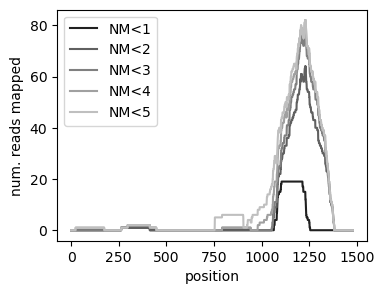

In [185]:
sample_id = 'no3_middle_2025_illumina_filtered'
# sample_id = 'env_75cm_2021_illumina_2_filtered'
# sample_id = 'env_95cm_2021_illumina_2'

path = os.path.join('../data/sr-vp/bowtie', f'{sample_id}.bam')

# mp_1	env_95cm_2021_illumina_2_filtered	

if not os.path.exists(os.path.join('../data/sr-vp/bowtie', f'{sample_id}.bam.bai')):
    subprocess.run(f'samtools index {path}', shell=True, check=True)


def plot_mapping(path, ref_id=None, func=np.sum, metric:str='mapped', ax=None, label=None, max_nm=7, read_length=150):


    figure_df = BamFile.from_file(path).to_df(ref_id=ref_id)
    figure_df['mapped'] = (~figure_df.unmapped).astype(int)
    figure_df = figure_df[figure_df.NM <= max_nm].copy()

    ref_length = figure_df.ref_length.iloc[0]
    positions = np.arange(ref_length)
    values = np.zeros((len(figure_df), len(positions)))

    for i, row in enumerate(figure_df.itertuples()):
        start = row.position
        stop = min(start + 150, ref_length)
        values[i, start:stop] = getattr(row, metric)

    values = func(values, axis=0)
    ax.plot(positions, values, label=label)
    ax.set_xlabel('position')

    stats = dict()
    stats['coverage'] = (read_length * len(figure_df)) / ref_length
    stats['variance'] = np.var(values)
    stats['coefficient_of_variance'] = np.sqrt(stats['variance']) / stats['coverage']
    stats['read_count'] = figure_df.mapped.sum()
    stats['fraction_covered'] = (values > 0).mean()
    return stats


fig, ax = plt.subplots(figsize=(4, 3))

for max_nm in [0, 1, 2, 3, 4]:
    # stats = plot_mapping(path, ref_id='mp_0', label=f'NM<{max_nm + 1}', ax=ax, max_nm=max_nm, metric='NM', func=np.mean)
    stats = plot_mapping(path, ref_id='mp_51', label=f'NM<{max_nm + 1}', ax=ax, max_nm=max_nm)
    print(f'NM < {max_nm + 1}:', stats)
ax.legend()
ax.set_ylabel('num. reads mapped')
plt.show()


bz_0 found in cluster 23
bz_11 found in cluster 13


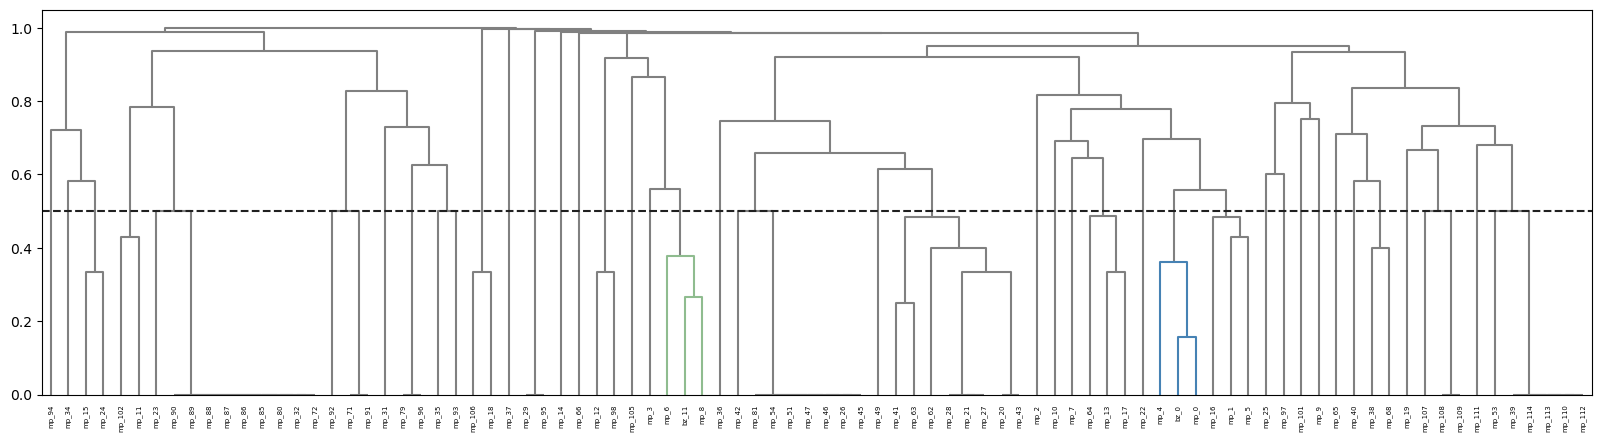

In [ ]:
# Want to construct a presence/absence matrix and look at which Methanoperedens species are most correlated with the Betazoids. 
# This should probably be done using a Jaccard distance matrix, and then clustering based on the matrix. 

# Jaccard distance only counts samples where at least one of the two values is "1" as contributing to the similarity score. 
# A distance value of 1 indicates there is no overlap between two species. 
# d(A or B) = 1 - sum(A and B) / sum(A or B)

max_distance = 0.5
min_coverage = 0

df = coverm_df[coverm_df.trimmed_mean > min_coverage].copy()
df = df.pivot(values='trimmed_mean', index='contig_id', columns='sample_id')
df = df.fillna(0)
df[df > 0] = 1


D = pdist(df.values, metric='jaccard')
Z = linkage(D, method='average')

leaves = leaves_list(Z)
labels = df.index.values[leaves]
clusters = fcluster(Z, t=max_distance, criterion='distance') # Essentially draws a horizontal line on the branch plot to delinieate clusters. 

bz_clusters = list()
for idx, cluster_id in enumerate(clusters):
    if df.index[idx].startswith('bz'):
        bz_clusters.append(cluster_id)
        print(f'{df.index[idx]} found in cluster {cluster_id}')

def get_cluster(node):
    '''Obtain the cluster associated with a particular node in the tree.'''
    if node.id < len(leaves):
        return clusters[node.id]

    left = get_cluster(node.left)
    right = get_cluster(node.right)

    if left == right:
        return left
    return None # If the leaves below the node are not homogenous, return None. 

# Create a tree object from the linkage matrix. 
_, nodes = scipy.cluster.hierarchy.to_tree(Z, rd=True) # Use rd=True to return the list of nodes rather than just the root. 

node_clusters = {node.id:get_cluster(node) for node in nodes}
colors = dict(zip(bz_clusters, ['steelblue', 'darkseagreen']))
node_colors = {node_id:colors.get(node_cluster, 'gray') for node_id, node_cluster in node_clusters.items()}

fig, ax = plt.subplots(figsize=(20, 5))

dendrogram = scipy.cluster.hierarchy.dendrogram(Z, no_plot=False, ax=ax, link_color_func=lambda k : node_colors[k], labels=df.index.values)
ax.axhline(max_distance, ls='--')

plt.show()

# The linkage matrix has a row for each  merge. 

<Axes: xlabel='log_ratio', ylabel='Density'>

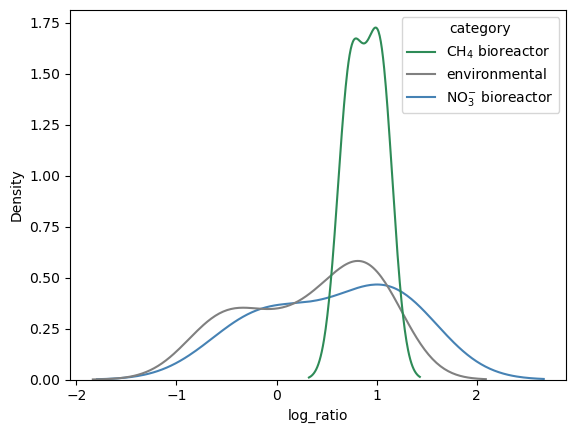

In [227]:
genome_ids = ['mp_8', 'bz_11']
# genome_ids = ['mp_6', 'bz_11']
genome_ids = ['mp_0', 'bz_0']

figure_df = coverm_df[coverm_df.trimmed_mean > min_coverage].copy()
figure_df = figure_df[figure_df.contig_id.isin(genome_ids)].copy()
figure_df = figure_df.pivot(index='sample_id', columns='contig_id', values='trimmed_mean')
figure_df = figure_df.fillna(0) + 1 # Add a pseudocount. 
figure_df['ratio'] = figure_df[genome_ids[1]] / figure_df[genome_ids[0]] # The log ratio is basically 
for genome_id in genome_ids:
    figure_df[genome_id] = np.log10(figure_df[genome_id])
figure_df['log_ratio'] = figure_df[genome_ids[1]] - figure_df[genome_ids[0]] # The log ratio is basically 

categories = dict()
categories['NO$_3^{-}$ bioreactor'] = figure_df.index.str.startswith('no3')
categories['CH$_4$ bioreactor'] = figure_df.index.str.startswith('ch4')
categories['environmental'] = figure_df.index.str.startswith('env')
# figure_df['bioreactor'] = ~figure_df.index.str.startswith('env')
figure_df['category'] = np.select(*list(zip(*list(categories.items())))[::-1], default='none')

fig, ax = plt.subplots()

palette = {'NO$_3^{-}$ bioreactor':'steelblue', 'CH$_4$ bioreactor':'seagreen', 'environmental':'gray'}
sns.kdeplot(figure_df, x='log_ratio', hue='category', palette=palette, common_norm=False)

# sns.scatterplot(figure_df, x=genome_ids[0], y=genome_ids[1], hue='bioreactor', palette=palette)
# x, y = figure_df[genome_ids[0]], figure_df[genome_ids[1]]
# m, b = np.polyfit(x, y, deg=1)
# x_min, x_max = ax.get_xlim()
# ax.plot(np.linspace(x_min, x_max, 100), b + np.linspace(x_min, x_max, 100) * m)
# print(f'y = {m:.3f}x + {b:.3f}')

In [ ]:
# coverm contig --bam-files /home/philippar/sr-vp/bbmap/*bam --methods length count mean trimmed_mean covered_fraction > /home/philippar/sr-vp/coverm/community.tsv
# coverm contig --include-secondary --bam-files /home/philippar/sr-vp/bbmap/*bam --methods length count mean trimmed_mean covered_fraction > /home/philippar/sr-vp/coverm/community.tsv

In [ ]:


# min_covered_bases_fraction = 0.8
# min_read_count = 5

# STATS_FIELDS = ['file_path', 'format', 'type', 'num_seqs', 'sum_len', 'min_len', 'avg_len', 'max_len']
# stats_df = pd.concat([pd.read_csv(path, names=STATS_FIELDS, sep=r'\s+', header=0) for path in glob.glob('../data/sr-vp/stats/*')])
# stats_df['file_name'] = stats_df.file_path.apply(os.path.basename)
# stats_df['num_seqs'] = stats_df.num_seqs.str.replace(',', '').astype(int)



In [ ]:
# First would like to check the coverm/bbmap-predicted coverages against the ones reported in ggkbase. 
GGKBASE_CONTIG_ID_TO_GENOME_ID_MAP = {'_'.join(ggkbase_gene_id.split('_')[:-1]):f'mp_{cluster_id}' for ggkbase_gene_id, cluster_id in cluster_id_map.items()} # Only the Methanoperedens.

GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP = SRVP_SAMPLE_METADATA_DF[~SRVP_SAMPLE_METADATA_DF.ggkbase_sample_id.isnull()].set_index('ggkbase_sample_id').sample_id.to_dict()
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP = {ggkbase_sample_id.replace('.', '_'):sample_id for ggkbase_sample_id, sample_id in GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP.items()}
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SR-VP_0-2'] = 'env_2cm_2017_illumina' # 'SR-VP_0-2cm_Biohub_180515'
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SR-VP_4-6'] = 'env_6cm_2017_illumina' # 'SR-VP_4-6cm_Biohub_180515'
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SR-VP_9_9_2021_72_4B_1_05m_2_METASPADES'] = 'env_105cm_2021_illumina_2'
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SR-VP_9_9_2021_75_5A_0_95m_2_METASPADES'] = 'env_95cm_2021_illumina_2'
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SR-VP_9_9_2021_81_5A_0_75m_2_METASPADES'] = 'env_75cm_2021_illumina_2'
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SR-VP_9_9_2021_87_5B_1_2m_2_METASPADES'] = 'env_120cm_2021_illumina_2'
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['Methanoperedens_44_19-type_SR-VP_26_10_2019_1_100cm_part'] = 'env_100cm_2019_illumina_1'
# GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SRVP19_trench_C_20cm_viral_megahit'] Missing
# GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SRVP19_trench_A_40cm-2_viral_idba'] Missing


get_ggkbase_sample_id = lambda ggkbase_contig_id : ggkbase_contig_id.split('_scaffold_')[0] if ('scaffold' in ggkbase_contig_id) else '_'.join(ggkbase_contig_id.split('_')[:-1])

mp_rps3_contigs_df = load_mp_rps3_contigs()[['coverage']]
mp_rps3_contigs_df = mp_rps3_contigs_df[~mp_rps3_contigs_df.index.str.contains('PACBIO', case=False)].copy()
mp_rps3_contigs_df['ggkbase_sample_id'] = [get_ggkbase_sample_id(ggkbase_contig_id) for ggkbase_contig_id in mp_rps3_contigs_df.index]
mp_rps3_contigs_df['sample_id'] = mp_rps3_contigs_df.ggkbase_sample_id.map(GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP)
mp_rps3_contigs_df['contig_id'] = mp_rps3_contigs_df.index.map(GGKBASE_CONTIG_ID_TO_GENOME_ID_MAP)
mp_rps3_contigs_df = mp_rps3_contigs_df.reset_index(names=['ggkbase_contig_id'])
mp_rps3_contigs_df = mp_rps3_contigs_df.merge(coverm_df, on=['sample_id', 'contig_id'], how='inner') #, validate='one_to_one')


In [ ]:
# min_num_samples = 3

# figure_df = coverm_df.copy()
# figure_df = figure_df[figure_df.contig_id.str.startswith('mp') | figure_df.contig_id.str.startswith('bz')].copy()
# figure_df = figure_df.pivot(index='contig_id', columns='sample_id', values='rpkm').fillna(0)
# # figure_df =  pd.DataFrame(np.where(figure_df < min_coverage, 0, 1), index=figure_df.index, columns=figure_df.columns)
# # figure_df[figure_df < min_coverage] = 0

# # print(f'Samples with no organism over the {min_coverage}x detection limit:', ' '.join(figure_df.columns[figure_df.T.sum(axis=1) == 0]))
# print(f'Number of organisms not detected in at least {min_num_samples} samples:', ((figure_df > 0).sum(axis=1) < min_num_samples).sum())
# # print(f'Organisms not found in at least {min_num_samples} samples:', ' '.join(figure_df[figure_df.sum(axis=1) < min_num_samples].index))

# figure_df = figure_df[(figure_df > 0).sum(axis=1) >= min_num_samples].copy()
# figure_df = np.log1p(figure_df)

# genome_order = get_order((figure_df.values > 0).astype(int), index=figure_df.index.values)
# sample_order = get_order((figure_df.values > 0).astype(int).T, index=figure_df.columns.values)
# # cmap = ListedColormap(['white', 'darkseagreen', 'steelblue'])
# # Replace values according to organism category (ECE or Methanoperedens). 
# # figure_df[figure_df.index.str.startswith('mp')] =  figure_df[figure_df.index.str.startswith('mp')].replace(1, 2)
# # figure_df[~figure_df.index.str.startswith('mp')] =  figure_df[~figure_df.index.str.startswith('mp')].replace(1, 1)

# fig, ax = plt.subplots(figsize=np.array(figure_df.shape)[::-1] / 3)
# figure_df = figure_df.loc[genome_order, sample_order]
# figure_df[figure_df == 0] = np.nan 

# sns.heatmap(figure_df, cbar=False, cmap='Blues', linecolor='white', linewidths=1)
# ax.set_ylabel('')
# ax.set_xlabel('')
# plt.show()

# # There should be a Methanoperedens with around 6x coverage, SR-VP_05_06_2024_N_bottom, in SR-VP_05_06_2024_N_bottom. 
# # SR-VP_05_06_2024_N_bottom_Black_host_Methanoperedens_44_7
# # Which one is the confirmed Betazoid host? Seems to be mp_10 (SRVP18_trench_2_45cm_scaffold_74960_2 representative, 99% match to SR-VP_Bioreactor_ck_bot_05_17_2025_Black_host_Methanoperedens_44_40)

In [ ]:
# rep_gene_ids = mp_reps_rps3_df.gene_id.unique() # The representative gene IDs. 
# gene_id_to_genome_id_map =  mp_reps_rps3_df.reset_index(drop=False).set_index('gene_id').genome_id.to_dict()
# genome_ids = ['mp_0', 'mp_17', 'mp_37']
# # Re-load the alignment DataFrame and obtain the percent identity between representatives. 


# cmap = plt.cm.Blues.copy()
# cmap.set_bad(color='gray')

# figure_df = pd.read_csv('../data/sr-vp/mp_rps3.tsv', sep='\t', names=MMSEQS_SEARCH_FIELDS.split(','))
# figure_df = figure_df[figure_df['query'].isin(rep_gene_ids) & figure_df['target'].isin(rep_gene_ids)].copy()
# figure_df['query_genome_id'] = figure_df['query'].map(gene_id_to_genome_id_map)
# figure_df['target_genome_id'] = figure_df['target'].map(gene_id_to_genome_id_map)
# figure_df = figure_df.pivot(index='query_genome_id', columns='target_genome_id', values='fident')

# # Matrix is not symmetric automatically, not completely sure why. 
# for i, j in itertools.product(range(len(figure_df)), range(len(figure_df))):
#     fidents = [figure_df.iloc[i, j], figure_df.iloc[j, i]]
#     fidents = [fident for fident in fidents if (not np.isnan(fident))]
#     if len(fidents) == 0:
#         continue 

#     figure_df.iloc[i, j] = max(fidents)
#     figure_df.iloc[j, i] = max(fidents)

# fig, ax = plt.subplots(figsize=(25, 25))

# sns.heatmap(figure_df, cmap=cmap, ax=ax, annot=True, cbar=False, linecolor='black', linewidth=0.7)
# ax.set_xlabel('')
# ax.set_ylabel('')

# for location, spine in ax.spines.items():
#     ax.spines[location].set_visible(True)

# plt.show()


# fig, axes = plt.subplots(figsize=(8, 4), ncols=2)

# ax = axes[0]
# figure_df = list()
# figure_df += [bam_df[bam_df.mp_0_mapped].assign(category='mp_0-mp_0 : mp_0').rename(columns={'mp_0_edit_distance':'edit_distance'})]
# figure_df += [bam_df[bam_df.mp_0_mapped].assign(category='mp_0-mp_0 : mp_reps').rename(columns={'mp_reps_edit_distance':'edit_distance'})]
# figure_df += [bam_df[bam_df.mp_reps_mapped].assign(category='mp_0-mp_reps : mp_reps').rename(columns={'mp_reps_edit_distance':'edit_distance'})] 
# figure_df += [bam_df[bam_df.mp_reps_mapped].assign(category='mp_0-mp_reps : mp_0').rename(columns={'mp_0_edit_distance':'edit_distance'})] 
# figure_df = pd.concat(figure_df).reset_index()

# sns.ecdfplot(figure_df, x='edit_distance', hue='category', stat='count', palette='Grays', ax=ax)
# ax.get_legend().set_title('')
# ax.set_xlim(xmin=0, xmax=30)
# ax.set_ylabel('count')
# ax.set_xlabel('edit distance')

# ax = axes[1]

# figure_df = coverm_dfs['mp_reps'].copy()
# sns.kdeplot(figure_df, x='coefficient_of_variance', color='gray')

# mp_0_cv = coverm_dfs['mp_0'].coefficient_of_variance.iloc[0] # Coefficient of variance for the reads mapped to mp_0 with the mp_reps reference. 
# ax.axvline(x=mp_0_cv, ls='--', color='steelblue', label='mp_0-mp_reps : mp_reps')

# mp_0_cv = coverm_dfs['mp_reps'][coverm_dfs['mp_reps'].contig_id == 'mp_0'].coefficient_of_variance.iloc[0] # Coefficient of variance for the reads mapped to mp_0 with the mp_0 reference. 
# ax.axvline(x=mp_0_cv, ls='--', color='darkseagreen', label='mp_0-mp_0 : mp_0')

# # It seems as though the variability is higher in the mp_0 only sample, suggesting that the full mapping might be slightly better. 

# ax.legend()

# ax.set_ylabel('density')
# ax.set_xlabel(r'coefficient of variance ($\frac{\sigma}{\mu}$)')

# fig.tight_layout
# plt.show()

# # Where are the reads going which had mapped to mp_0 when mp_0 was the only reference?
# print('Where do the reads mapped to mp_0 in the mp_0_rps3 mapping get placed in the mp_reps_rps3 mapping?')
# for row in bam_df[bam_df.mp_0_mapped].mp_reps_ref_id.value_counts().reset_index().itertuples():
#     print(f'{row.mp_reps_ref_id}\t{row.count}')



In [ ]:
# mp_rps3_df['genome_id'] = mp_rps3_df.cluster_id.apply(lambda cluster_id : f'mp_{cluster_id}')
# mp_rps3_df['coverage'] = mp_rps3_df.contig_id.map(mp_rps3_contigs_df.coverage).astype(float)

# coverm_df = coverm_dfs['mp_reps'].copy().rename(columns={'contig_id':'genome_id', 'trimmed_mean':'coverage'})
# coverm_df['ggkbase_coverage'] = coverm_df.genome_id.map(mp_rps3_df[mp_rps3_df.project_id == 'SR-VP_Bioreactor_N_bot_05_17_2025'].set_index('genome_id').coverage)

# coverm_df['coverage_diff'] = np.abs(coverm_df.coverage.astype(float) - coverm_df.ggkbase_coverage.astype(float))
# coverm_df['coverage_diff_fraction'] = coverm_df.coverage_diff / coverm_df.coverage

# print('Maximum difference between ggKbase and predicted coverages:', coverm_df.coverage_diff.max())
# print('Maximum fractional difference between ggKbase and predicted coverages:', coverm_df.coverage_diff_fraction.max())
# print('Mean difference between ggKbase and predicted coverages:', coverm_df.coverage_diff.mean())
# print('Mean fractional difference between ggKbase and predicted coverages:', coverm_df.coverage_diff_fraction.mean())

# # coverm_df[coverm_df.read_count > 0].sort_values('coverage', ascending=False).set_index('genome_id')[['read_count', 'coverage', 'coefficient_of_variance', 'ggkbase_coverage', 'coverage_diff']]

# # Inspection of the coverage variance from the bowtie mapping suggests that there might be some problem with reads mapping to only one of many possible valid locations
# # e.g. with mp_17, which has a CV of 1.16 and a coverage of >7x despite not being represented by a contig in the sample. To address this, I re-ran bowtie mapping with the -a
# # option, so that all valid mappings are reported. The result (including secondary alignments), ended up with coverage values which differed more from ggKbase overall, 
# # so I think sticking with only best mappings is a good idea. It could be that this approach is simply more sensitive to small taxonomical differences (which is what
# # I wanted anyway).